In [1]:

from nhs_waiting_lists.constants import proj_db_path
import sys

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text, bindparam

from nhs_waiting_lists.utils.proj_paths import find_project_root

project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

DB_PATH = project_root / proj_db_path / "nhs_consolidated.db"
DATA_DIR = "./data"

# conn = sqlite3.connect(DB_PATH)

conn = create_engine(f"sqlite:///{DB_PATH}")

ModuleNotFoundError: No module named 'nhs_waiting_lists.utils.proj_paths'

In [3]:
PROVIDER_CODES = ['R0B', 'RAJ', 'RTH', 'RTE', "RTF", "RWF", "RTE", "REF", "RWH", "R0B", "RVJ", "RHW",
                  "RDU", "RH8", "RWY", "RXC", "RL4", "RDE", "RXK", "RXR", "RJ2", "RN5", "RHU",
                  "RGN", "RWP", "RWD", "RAJ"]
TREATMENT_CODES = ('C_101', 'C_110', 'C_320', 'C_330', 'C_400', 'C_502', 'C_301')

In [4]:


query = text("""
             SELECT i.period,
                    i.provider_code                          as provider,
                    i.treatment_function_code                as treatment_code,
                    i.incomplete                             as incomplete,
                    i.incomplete_prev,
                    i.incomplete - i.incomplete_prev         AS inc_diff,
                    ((i.incomplete / i.incomplete_prev) - 1) AS frac_change,

                    i.admitted,
                    i.admitted_prev,
                    i.nonadmitted,
                    i.nonadmitted_prev,
                    i.new_periods,
                    i.new_periods_prev,
                    -- the accunting identity
                    (
                        i.incomplete
                            - (i.incomplete_prev
                                   + i.new_periods
                            - i.nonadmitted
                            - i.admitted
                            ))                               AS residual,
                    i.new_periods
                        - i.admitted
                        - i.nonadmitted
                                                             AS delta
             FROM metrics AS i
             WHERE i.provider_code IN :provider_codes
               AND treatment_function_code IN :treatment_codes
             ORDER BY provider ASC, treatment_function_code ASC, i.period ASC; \
             """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

df = pd.read_sql(query, conn, params={
    'provider_codes': PROVIDER_CODES,
    'treatment_codes': TREATMENT_CODES}
                 )  # type: ignore[arg-type]
df = df.assign(
    inc_diff=df["incomplete"] - df["incomplete_prev"],
)
df = df.assign(
    residual_check_diff=df['incomplete_prev'] - df['delta']
)
df = df.assign(
    residual_check=(df['residual'] - df['residual_check_diff']).abs().max()
)



In [5]:
df.query('provider == "R0B" and treatment_code == "C_320"')[
    [
        "period",
        "incomplete",
        "incomplete_prev",
        "inc_diff",
        "residual",
        "delta",
        "residual_check"
    ]
]

,period,incomplete,incomplete_prev,inc_diff,residual,delta,residual_check
231,2019-04-01,986.0,NaN,NaN,NaN,129.0,19372.0
232,2019-05-01,963.0,986.0,-23.0,-141.0,118.0,19372.0
233,2019-06-01,899.0,963.0,-64.0,-111.0,47.0,19372.0
234,2019-07-01,1026.0,899.0,127.0,-84.0,211.0,19372.0
235,2019-08-01,1004.0,1026.0,-22.0,-189.0,167.0,19372.0
...,...,...,...,...,...,...,...
303,2025-04-01,1733.0,1807.0,-74.0,-124.0,50.0,19372.0
304,2025-05-01,1700.0,1733.0,-33.0,-123.0,90.0,19372.0
305,2025-06-01,1694.0,1700.0,-6.0,-88.0,82.0,19372.0
306,2025-07-01,1781.0,1694.0,87.0,-101.0,188.0,19372.0


In [6]:
from plotnine import (
    scale_x_datetime
)

df2 = df.query('provider == "R0B" and treatment_code == "C_301"')[
    [
        "period",
        "incomplete",
        "incomplete_prev",
        "inc_diff",
        "residual",
        "admitted",
        "nonadmitted",
        "new_periods",
        "delta",
    ]
]

df2

,period,incomplete,incomplete_prev,inc_diff,residual,admitted,nonadmitted,new_periods,delta
154,2019-04-01,1043.0,NaN,NaN,NaN,230.0,299.0,635.0,106.0
155,2019-05-01,1146.0,1043.0,103.0,-66.0,254.0,282.0,705.0,169.0
156,2019-06-01,1156.0,1146.0,10.0,-57.0,310.0,302.0,679.0,67.0
157,2019-07-01,1247.0,1156.0,91.0,-58.0,256.0,425.0,830.0,149.0
158,2019-08-01,1248.0,1247.0,1.0,-110.0,322.0,357.0,790.0,111.0
...,...,...,...,...,...,...,...,...,...
226,2025-04-01,1178.0,1234.0,-56.0,-89.0,289.0,704.0,1026.0,33.0
227,2025-05-01,1123.0,1178.0,-55.0,-84.0,223.0,709.0,961.0,29.0
228,2025-06-01,1089.0,1123.0,-34.0,-121.0,212.0,684.0,983.0,87.0
229,2025-07-01,1125.0,1089.0,36.0,-101.0,240.0,712.0,1089.0,137.0


In [7]:
import statsmodels.api as sm

df3 = df2.dropna()

X = sm.add_constant(df3['delta'])
y = df3['residual']
ols = sm.OLS(y, X).fit(cov_type='HC3')
print(ols.params, ols.rsquared)
print(ols.summary2())

const   -146.852151
delta      0.258789
dtype: float64 0.1196256254787943
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.108   
Dependent Variable: residual         AIC:                840.0244
Date:               2025-10-15 06:00 BIC:                844.6859
No. Observations:   76               Log-Likelihood:     -418.01 
Df Model:           1                F-statistic:        0.9723  
Df Residuals:       74               Prob (F-statistic): 0.327   
R-squared:          0.120            Scale:              3601.5  
------------------------------------------------------------------
           Coef.    Std.Err.     z     P>|z|     [0.025    0.975] 
------------------------------------------------------------------
const    -146.8522   35.8094  -4.1009  0.0000  -217.0372  -76.6671
delta       0.2588    0.2625   0.9860  0.3241    -0.2556    0.7732
-----------------------------------------------------------------
Omnibus:      

In [8]:

child_long = df2.reset_index().melt(
    id_vars=['period'],
    value_vars=['residual', 'delta', 'inc_diff', 'new_periods', 'nonadmitted', 'admitted'],
    var_name='metric',
    value_name='value'
)


# child_long = child_long.groupby('metric').apply(
#     lambda x: x[(x['value'] >= x['value'].quantile(0.05)) &
#                 (x['value'] <= x['value'].quantile(0.95))],
#     include_groups=True
# ).reset_index(drop=True)

def remove_outliers(group: pd.DataFrame) -> pd.DataFrame:
    Q1 = group['value'].quantile(0.25)
    Q3 = group['value'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['value'] >= lower) & (group['value'] <= upper)]


child_long = child_long.groupby('metric').apply(remove_outliers).reset_index(drop=True)

child_long

/tmp/ipykernel_2989947/3306991541.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,period,metric,value
0,2019-04-01,admitted,230.0
1,2019-05-01,admitted,254.0
2,2019-07-01,admitted,256.0
3,2019-09-01,admitted,145.0
4,2019-10-01,admitted,146.0
...,...,...,...
442,2025-04-01,residual,-89.0
443,2025-05-01,residual,-84.0
444,2025-06-01,residual,-121.0
445,2025-07-01,residual,-101.0


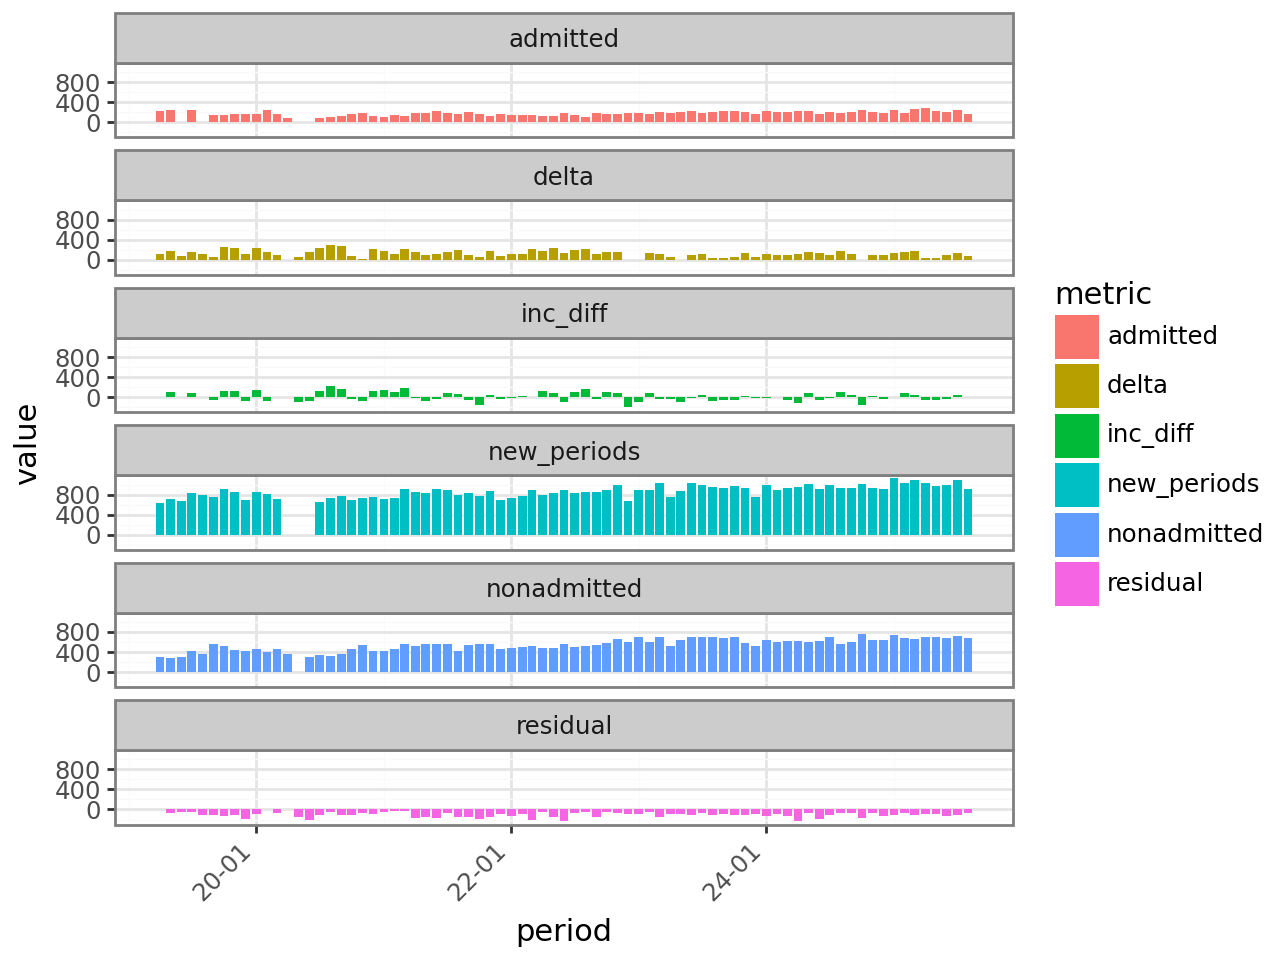

In [9]:
from plotnine import ggplot, aes, geom_col, facet_wrap, theme_bw, theme, element_text

p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # side-by-side bars
        + facet_wrap("~metric", ncol=1)
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p



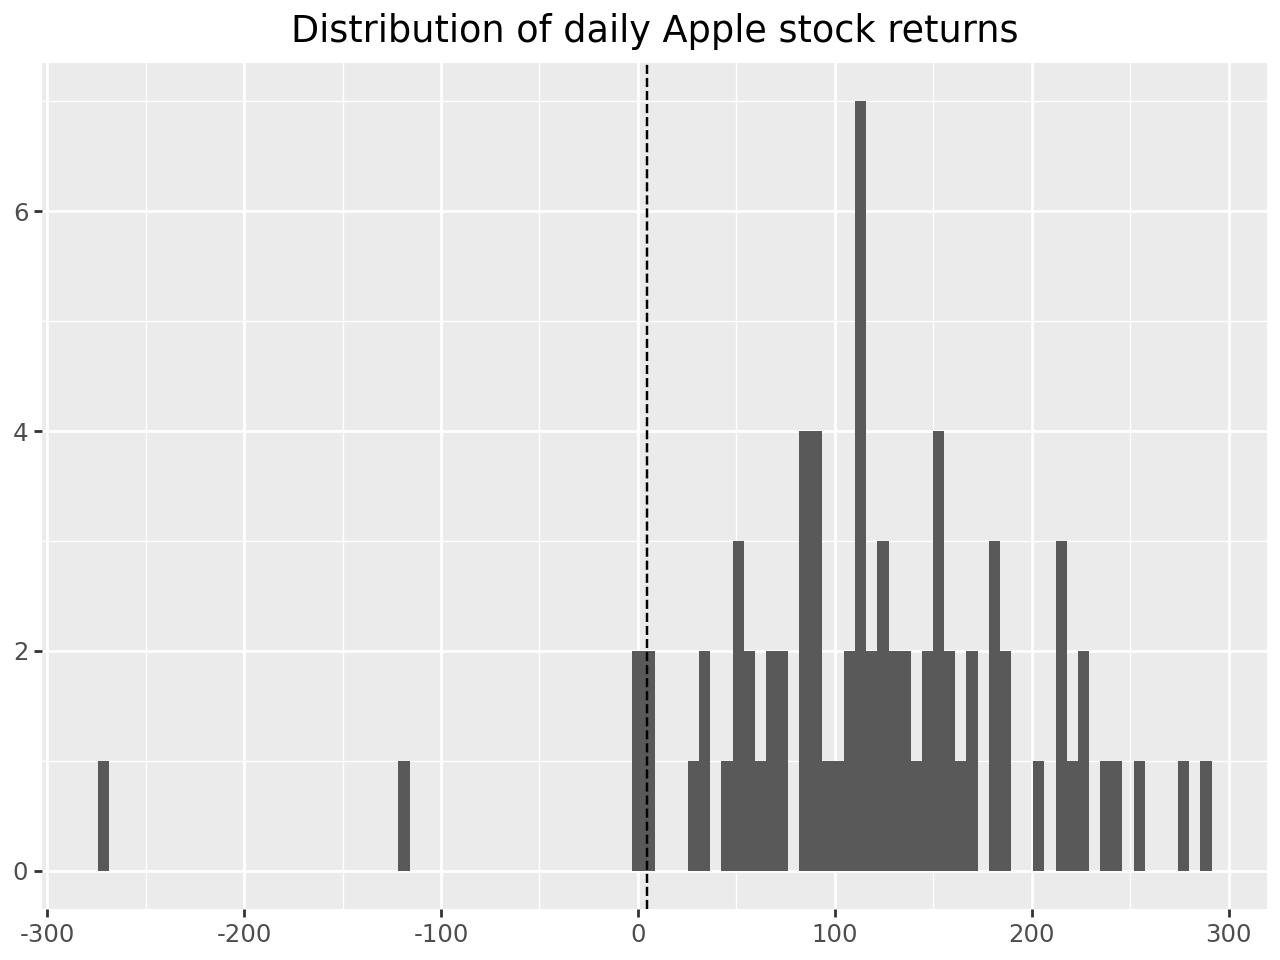

In [10]:
from mizani.formatters import percent_format
from plotnine import (
    ggplot, aes, geom_histogram, geom_vline, geom_qq,
    labs, scale_x_continuous, facet_wrap, theme_minimal,
    stat_qq_line, geom_density
)

quantile_05 = df2["delta"].quantile(0.05)

apple_returns_figure = (
        ggplot(df2, aes(x="delta"))
        + geom_histogram(bins=100)
        + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
        + labs(x="", y="", title="Distribution of daily Apple stock returns")

)
apple_returns_figure.show()

In [11]:
child_long.groupby("metric")["value"].quantile(0.05).reset_index()

,metric,value
0,admitted,112.40
1,delta,22.70
2,inc_diff,-108.20
3,new_periods,686.80
4,nonadmitted,322.25
5,residual,-202.50


In [12]:

quantiles = child_long.groupby("metric")["value"].quantile(0.05).reset_index()
quantiles.columns = ["return_type", "q05"]
quantiles

,return_type,q05
0,admitted,112.40
1,delta,22.70
2,inc_diff,-108.20
3,new_periods,686.80
4,nonadmitted,322.25
5,residual,-202.50


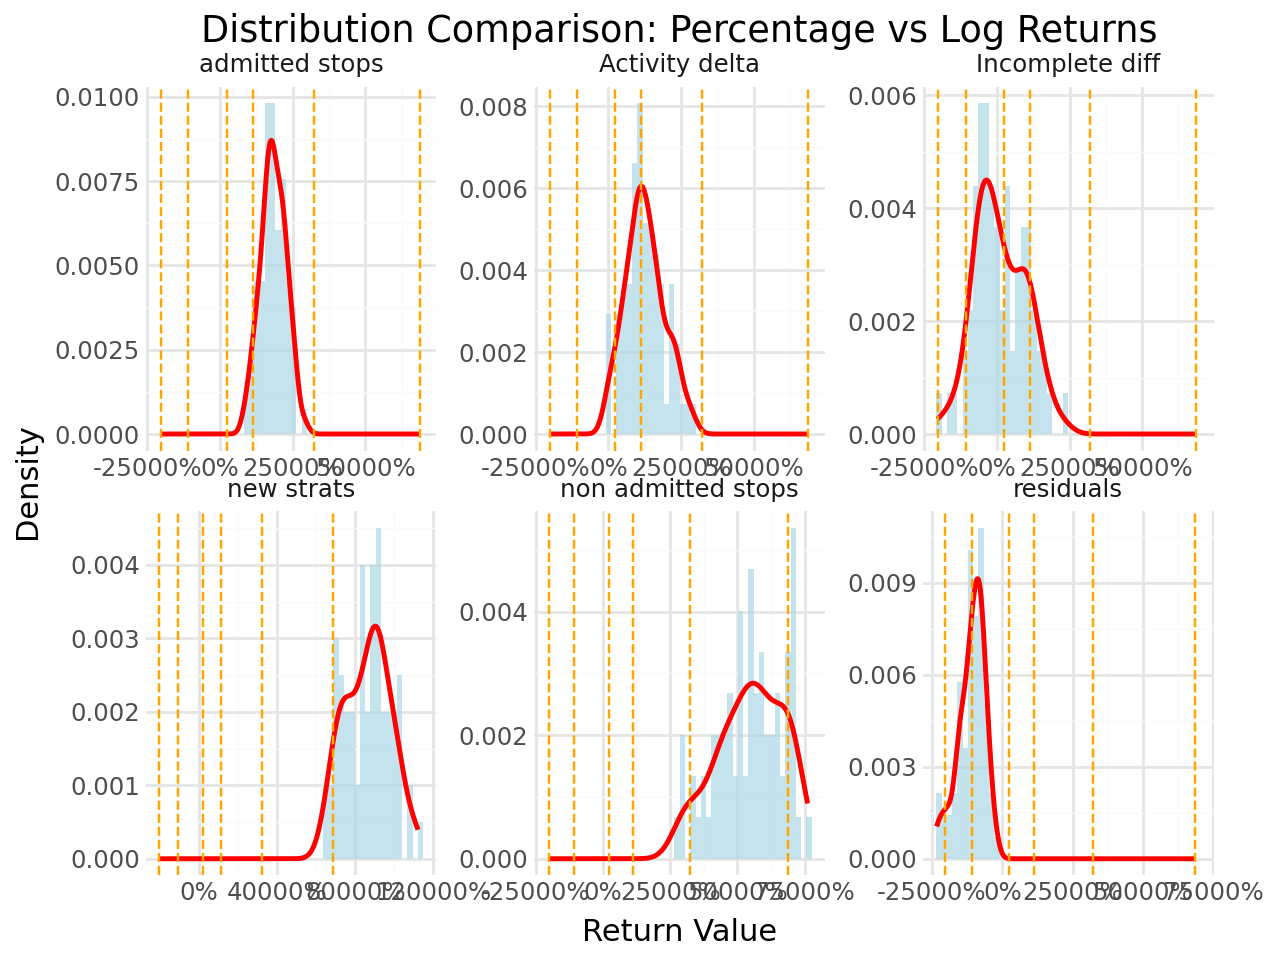

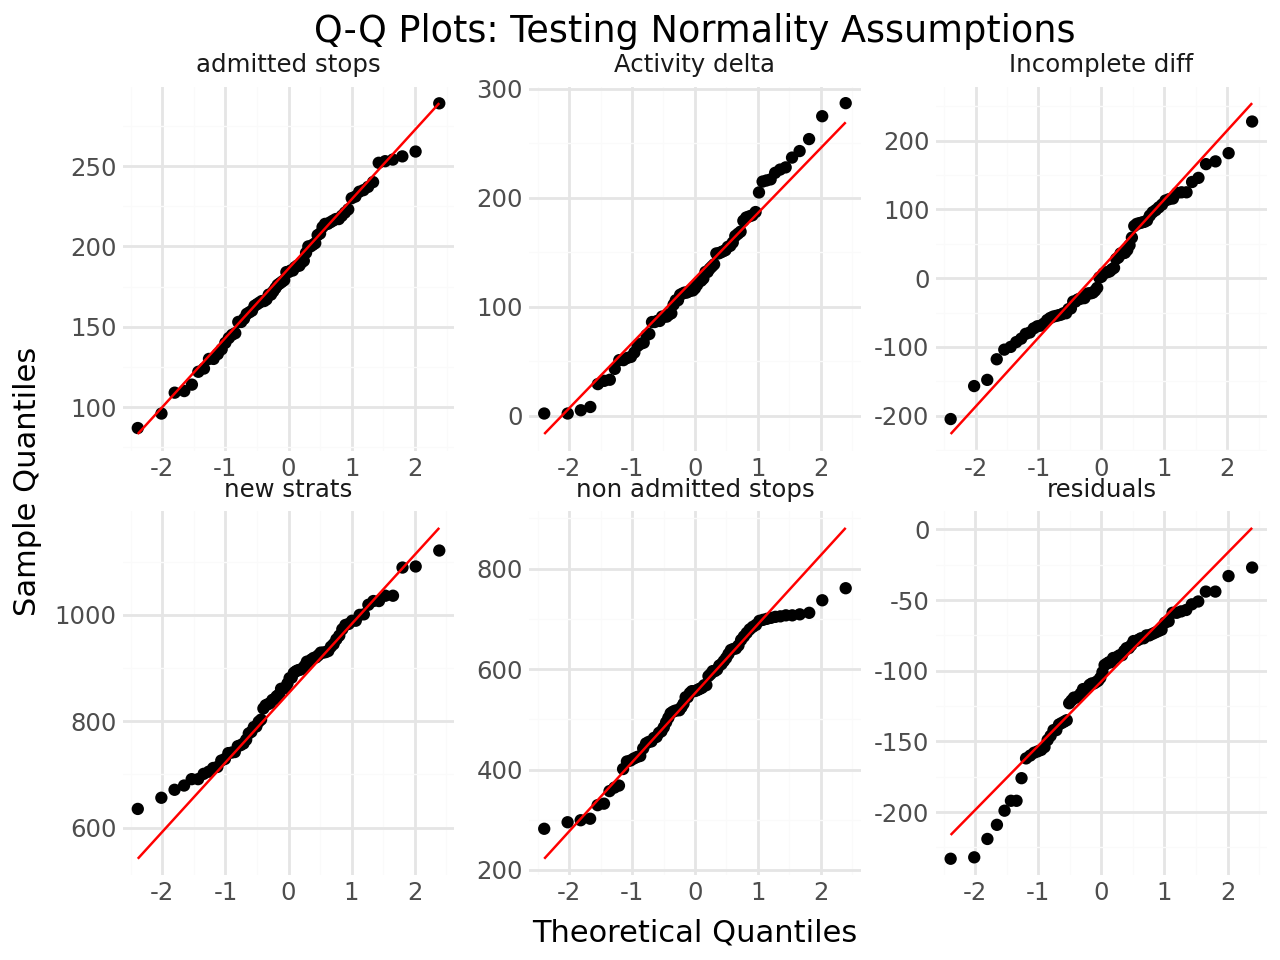


Normality Test Results:
    return_type  n_obs      mean       std  skewness  kurtosis  shapiro_stat  \
0         Delta     77  117.3896   84.3602   -1.2764    4.9738        0.9150   
1      Residual     76 -116.4342   63.5323   -2.4615   10.2999        0.8127   
2  Non Admitted     77  542.0779  128.8834   -0.5055   -0.3230        0.9654   
3      Admitted     77  183.4156   52.6456   -0.1772    0.9139        0.9838   
4   New Periods     77  842.8831  159.2059   -1.5660    4.5182        0.8887   

   shapiro_p   jb_stat    jb_p  is_normal_shapiro  is_normal_jb  
0     0.0001  100.2777  0.0000              False         False  
1     0.0000  412.6953  0.0000              False         False  
2     0.0344    3.6136  0.1642              False          True  
3     0.4357    3.0826  0.2141               True          True  
4     0.0000   96.9658  0.0000              False         False  


In [21]:

from nhs_waiting_lists.utils.normality import test_normality

returns_comparison = (
        ggplot(child_long, aes(x="value"))
        + geom_histogram(aes(y="..density.."), bins=50, alpha=0.7, fill="lightblue")
        + geom_density(color="red", size=1)
        + geom_vline(
    data=quantiles,
    mapping=aes(xintercept="q05"),
    linetype="dashed",
    color="orange"
)
        + facet_wrap("metric", scales="free", labeller=lambda x: {
    "delta": "Activity delta",
    "admitted": "admitted stops",
    "nonadmitted": "non admitted stops",
    "inc_diff": "Incomplete diff",
    "new_periods": "new strats",
    "residual": "residuals",
}[x])
        + labs(
    x="Return Value",
    y="Density",
    title="Distribution Comparison: Percentage vs Log Returns"
)
        + scale_x_continuous(labels=percent_format())
        + theme_minimal()
)

# For Q-Q plots to test normality more directly
qq_plot = (
        ggplot(child_long, aes(sample="value"))
        + geom_qq()
        + stat_qq_line(color="red")
        + facet_wrap("metric", scales="free", labeller=lambda x: {
    "delta": "Activity delta",
    "admitted": "admitted stops",
    "nonadmitted": "non admitted stops",
    "inc_diff": "Incomplete diff",
    "new_periods": "new strats",
    "residual": "residuals",
}[x])
        + labs(
    x="Theoretical Quantiles",
    y="Sample Quantiles",
    title="Q-Q Plots: Testing Normality Assumptions"
)
        + theme_minimal()
)

returns_comparison.show()
qq_plot.show()

pct_results = test_normality(df2["delta"].dropna(), "Delta")
log_results = test_normality(df2["residual"].dropna(), "Residual")
nap_results = test_normality(df2["nonadmitted"].dropna(), "Non Admitted")
ap_results = test_normality(df2["admitted"].dropna(), "Admitted")
np_results = test_normality(df2["new_periods"].dropna(), "New Periods")

normality_df = pd.DataFrame([pct_results, log_results, nap_results, ap_results, np_results])
print("\nNormality Test Results:")
print(normality_df.round(4))

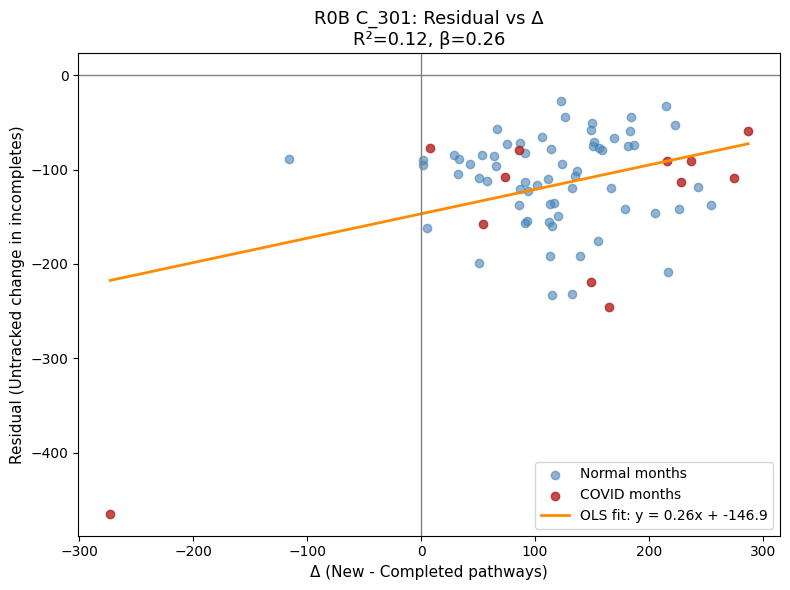

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pandas as pd

provider = "R0B"
treatment = "C_301"

df3 = df2.dropna(subset=['delta', 'residual']).copy()

# Fit OLS
X = sm.add_constant(df3['delta'])
y = df3['residual']
ols = sm.OLS(y, X).fit(cov_type='HC3')

# Predictions
xvals = np.linspace(df3['delta'].min(), df3['delta'].max(), 200)
yhat = ols.params['const'] + ols.params['delta'] * xvals

# Parse period and flag COVID
df3['period'] = pd.to_datetime(df3['period'])
covid = (df3['period'].dt.year == 2020)

# --- Plot starts here ---
plt.figure(figsize=(8, 6))

# Scatter: two colours in same figure
plt.scatter(df3.loc[~covid, 'delta'], df3.loc[~covid, 'residual'],
            alpha=0.6, color='steelblue', label='Normal months')
plt.scatter(df3.loc[covid, 'delta'], df3.loc[covid, 'residual'],
            alpha=0.8, color='firebrick', label='COVID months')

# Regression line
plt.plot(xvals, yhat, color='darkorange', lw=2,
         label=f"OLS fit: y = {ols.params['delta']:.2f}x + {ols.params['const']:.1f}")

# Formatting
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlabel("Δ (New - Completed pathways)", fontsize=11)
plt.ylabel("Residual (Untracked change in incompletes)", fontsize=11)
plt.title(f"{provider} {treatment}: Residual vs Δ\nR²={ols.rsquared:.2f}, β={ols.params['delta']:.2f}", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()



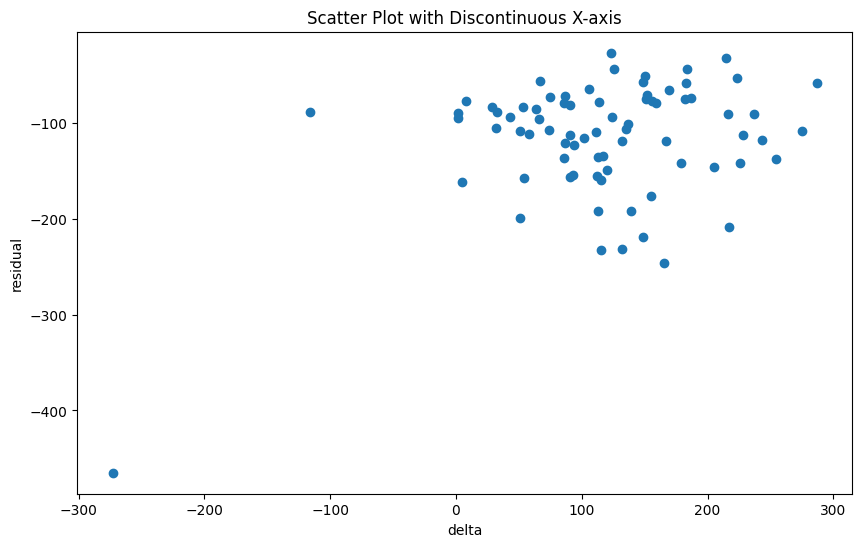

In [15]:
import matplotlib.pyplot as plt

x = np.concatenate(([5, 6, 7, 8, 9, 10], [1, 2, 3, 4]))
y = np.random.rand(10)

plt.figure(figsize=(10, 6))
plt.scatter(df3["delta"], df3["residual"])
plt.xlabel('delta')
plt.ylabel('residual')
plt.title('Scatter Plot with Discontinuous X-axis')
plt.show()

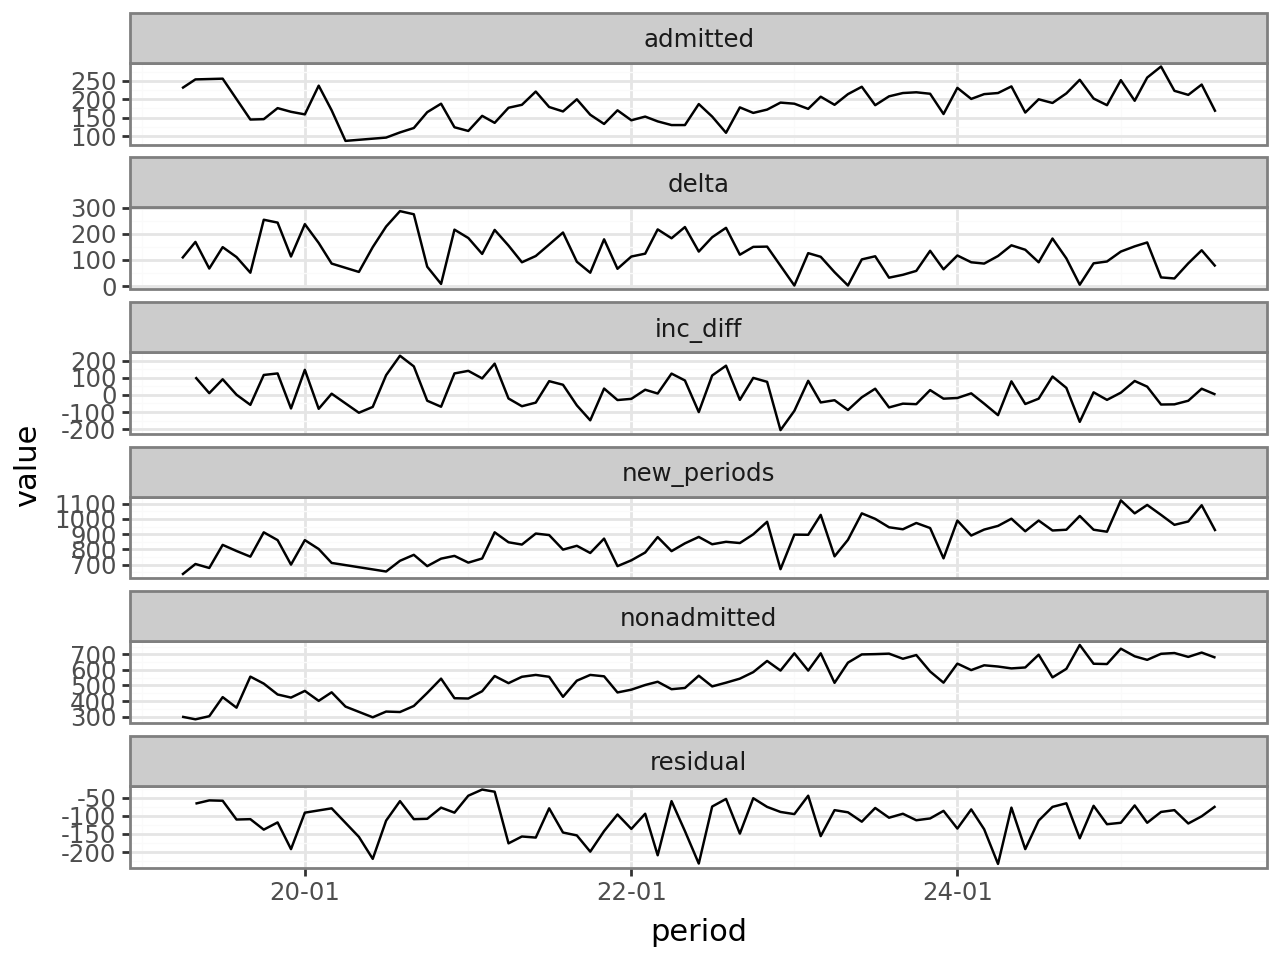

In [16]:
from plotnine import geom_line

p = (
        ggplot(child_long, aes(x="period", y="value", group=1))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_line()
        + facet_wrap("~metric", ncol=1, scales="free_y")  # or ncol=2 for side-by-side
        + theme_bw()
)
p

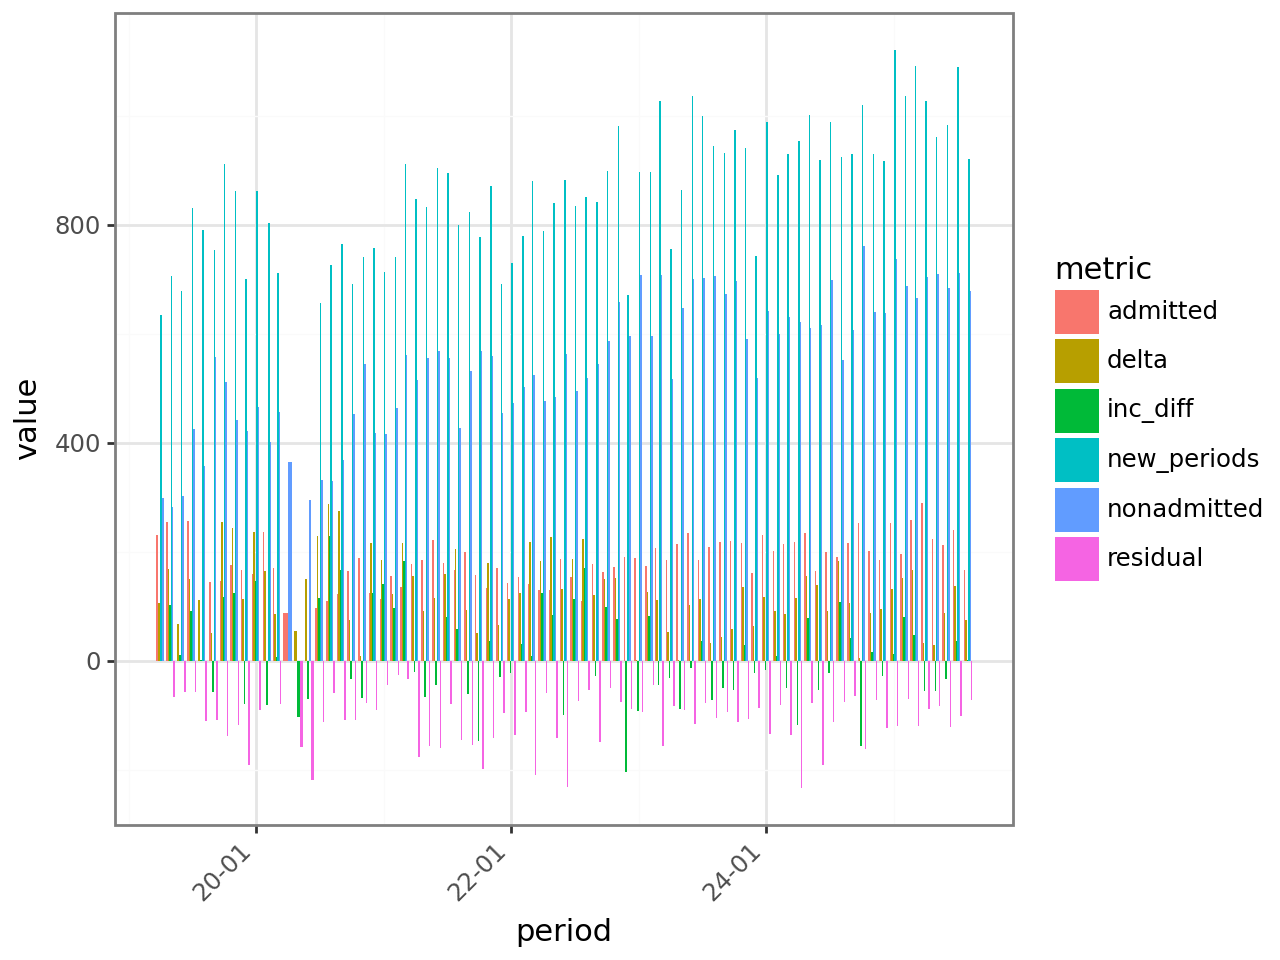

In [17]:
p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # or position="stack" for stacked
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p

In [18]:
returns_wide = (
    df.query("treatment_code == 'C_101'")
    .pivot(
        index="period",
        columns="provider",
        values="frac_change"
    )
    .reset_index()
)

returns_wide

provider,period,R0B,RAJ,RDE,RDU,REF,RGN,RH8,RHU,RHW,...,RTH,RVJ,RWD,RWF,RWH,RWP,RWY,RXC,RXK,RXR
0,2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,NaN,0.028679,0.052955,0.000000,-0.072455,0.021695,0.035657,0.054479,-0.119658,...,-0.022664,0.001005,0.014895,-0.014112,0.145679,0.009619,0.046078,-0.056781,-0.026420,-0.016718
2,2019-03-01,NaN,0.025594,0.026718,-0.062969,-0.041317,0.010617,0.009764,-0.081967,-0.090615,...,-0.018930,-0.019322,0.065847,-0.040967,-0.065194,-0.008213,-0.016256,-0.016949,-0.020353,-0.017632
3,2019-04-01,NaN,0.021390,0.043954,0.072400,0.016835,-0.036187,0.015776,0.028680,0.046263,...,0.018813,0.031986,-0.020097,-0.065878,0.107781,0.004969,-0.068763,0.087396,-0.000693,0.077564
4,2019-05-01,-0.054006,0.174520,0.023251,-0.005968,-0.017219,0.001211,-0.042585,0.027354,0.022676,...,0.103693,0.055046,-0.020129,-0.032507,0.055671,-0.046803,-0.021752,-0.026244,-0.052668,-0.067817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025-04-01,-0.019841,-0.020139,-0.034176,-0.013164,-0.006393,-0.084497,0.025736,-0.015937,0.004555,...,0.018936,0.020935,-0.039809,-0.027539,-0.058646,-0.051566,-0.002316,0.040404,-0.044122,0.011490
76,2025-05-01,0.003873,0.004524,-0.011444,0.025548,0.007507,-0.051730,-0.023881,-0.203475,-0.012778,...,-0.049624,-0.062884,-0.004717,-0.012872,-0.029088,-0.020220,-0.008706,-0.005049,-0.035931,-0.062145
77,2025-06-01,0.009995,-0.015859,-0.017033,-0.029541,-0.053220,0.069474,-0.001858,-0.039926,-0.023800,...,-0.065529,-0.010066,-0.038663,0.018629,-0.053786,-0.051594,0.017564,-0.003318,-0.004014,0.042038
78,2025-07-01,0.043576,0.020889,-0.035738,-0.049750,-0.059584,0.013333,0.025132,-0.070851,0.004705,...,-0.013357,-0.013410,-0.029061,0.040600,-0.002742,0.024662,-0.045455,0.011357,-0.002591,-0.046838
